In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/monthly_features.csv', encoding='latin-1')

In [3]:
df.head()

,Year,Month,Total_Sales,Avg_Sales,Order_count,Customer_count,Lag_1,Lag_2,Lag_3,Lag_6,...,Rolling_6,Rolling_12,Mom_1,Mom_3,Growth_rate,Quarter,Month_Sin,Month_Cos,Is_Holiday_Month,Is_Quarter_END
0,2016,1,18066.9576,316.964168,29,28,68167.0585,77907.6607,31453.3930,33781.5430,...,53341.786417,39988.017342,-50100.1009,-13386.4354,-73.496058,1,0.500000,8.660254e-01,1,0
1,2016,2,11951.4110,186.740797,36,36,18066.9576,68167.0585,77907.6607,27117.5365,...,50722.688850,40309.788225,-6115.5466,-65956.2497,-33.849344,1,0.866025,5.000000e-01,0,0
2,2016,3,32339.3184,252.650925,75,74,11951.4110,18066.9576,68167.0585,81623.5268,...,48195.001267,40929.081475,20387.9074,-35827.7401,170.589961,1,1.000000,6.123234e-17,0,1
3,2016,4,34154.4685,214.807978,71,68,32339.3184,11951.4110,18066.9576,31453.3930,...,39980.966533,39023.541592,1815.1501,16087.5109,5.612827,2,0.866025,-5.000000e-01,0,0
4,2016,5,29959.5305,209.507206,72,67,34154.4685,32339.3184,11951.4110,77907.6607,...,40431.145783,39544.176050,-4194.9380,18008.1195,-12.282252,2,0.500000,-8.660254e-01,0,0


In [4]:
print("Dataset Shape : ",df.shape)
print("Columns : ",df.columns.to_list())
print("Missing : \n",df.isnull().sum())

Dataset Shape :  (36, 22)
Columns :  ['Year', 'Month', 'Total_Sales', 'Avg_Sales', 'Order_count', 'Customer_count', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12', 'Rolling_3', 'Rolling_6', 'Rolling_12', 'Mom_1', 'Mom_3', 'Growth_rate', 'Quarter', 'Month_Sin', 'Month_Cos', 'Is_Holiday_Month', 'Is_Quarter_END']
Missing : 
 Year                0
Month               0
Total_Sales         0
Avg_Sales           0
Order_count         0
Customer_count      0
Lag_1               0
Lag_2               0
Lag_3               0
Lag_6               0
Lag_12              0
Rolling_3           0
Rolling_6           0
Rolling_12          0
Mom_1               0
Mom_3               0
Growth_rate         0
Quarter             0
Month_Sin           0
Month_Cos           0
Is_Holiday_Month    0
Is_Quarter_END      0
dtype: int64


###Correlation Analysis

In [6]:
features_cols = [
    'Year', 'Month', 'Quarter', 'Month_Sin', 'Month_Cos',
    'Is_Holiday_Month', 'Is_Quarter_END', 'Lag_1', 'Lag_2', 'Lag_3',
    'Lag_6', 'Rolling_3', 'Rolling_6', 'Mom_1', 'Growth_rate', 'Order_count', 'Customer_count'
]

available = [c for c in features_cols if c in df.columns]

target = 'Total_Sales'

corr_with_target = df[available + [target]].corr()[target].drop(target).sort_values(ascending=False)

print('Correlation with Target (Total_Sales) : ')
print(corr_with_target)

Correlation with Target (Total_Sales) : 
Order_count         0.934403
Customer_count      0.930517
Month               0.753009
Quarter             0.688108
Mom_1               0.533306
Lag_1               0.458175
Is_Holiday_Month    0.418956
Growth_rate         0.384793
Rolling_3           0.372220
Month_Cos           0.367216
Year                0.364153
Is_Quarter_END      0.316504
Rolling_6           0.237586
Lag_3               0.172327
Lag_2               0.151108
Lag_6               0.070899
Month_Sin          -0.447966
Name: Total_Sales, dtype: float64


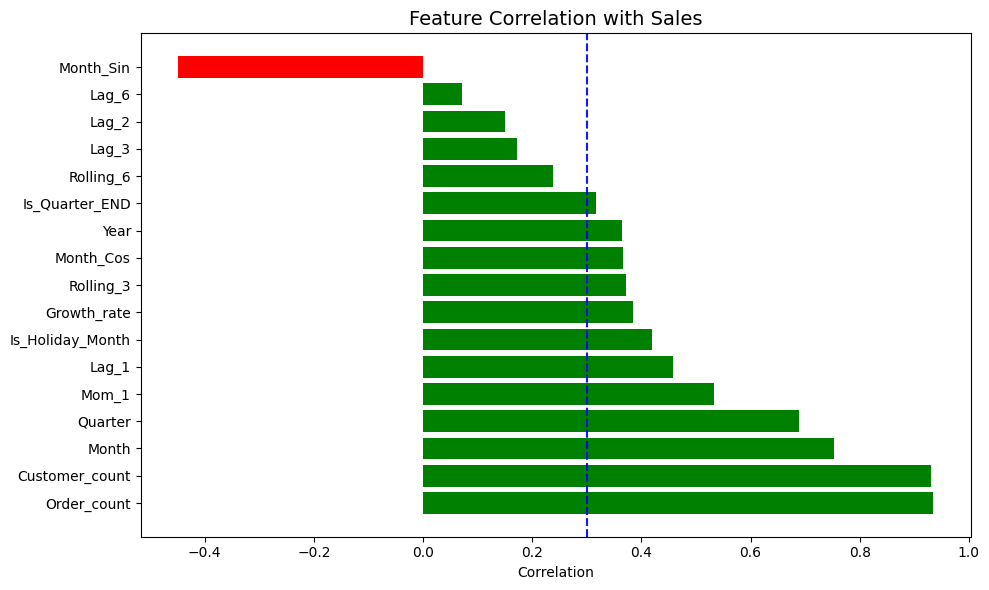

In [8]:
import os

plt.figure(figsize=(10,6))
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
plt.barh(
    corr_with_target.index,
    corr_with_target.values,
    color=colors
)
plt.axvline(x=0.3, color='blue', linestyle='--', alpha=0.7, label='Threshold 0.3')
plt.axvline(x=0.3, color='blue', linestyle='--', alpha=0.7)

plt.title('Feature Correlation with Sales', fontsize=14)
plt.xlabel('Correlation')
plt.tight_layout()


os.makedirs('notebooks', exist_ok=True)
plt.savefig('notebooks/07_correlation.png',dpi=150)
plt.show()

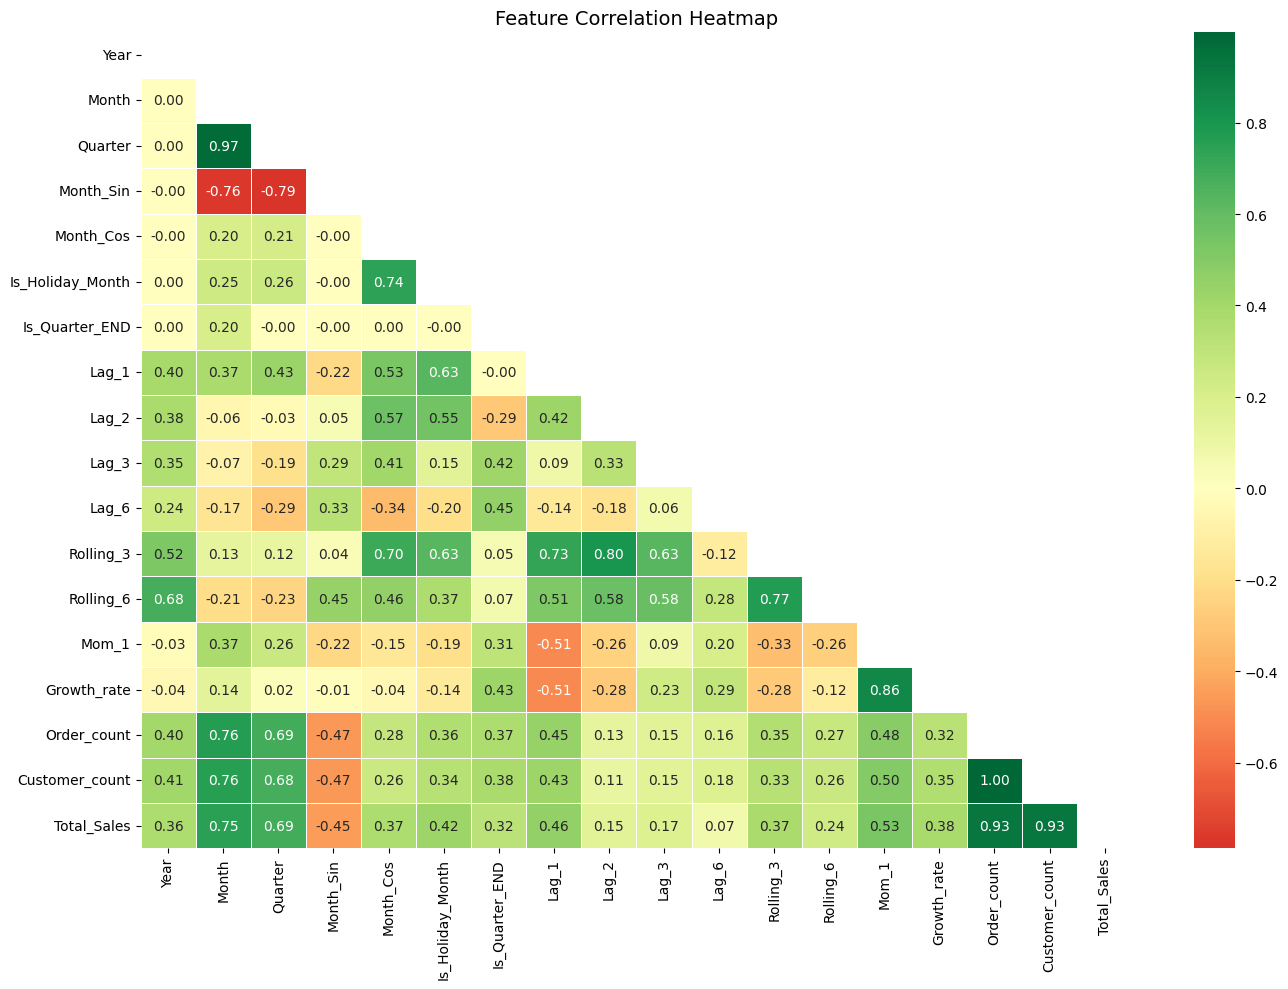

In [9]:
plt.figure(figsize=(14,10))
corr_matrix = df[available + [target]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidth=0.5
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('notebooks/08_heatmap.png',dpi=150)
plt.show()

###Feature Importance

In [10]:
data = df[available + [target]].dropna()
X = data[available]
y = data[target]

In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_,index=available).sort_values(ascending=False)
print("Random Forest Feature Importance :")
print(rf_importance)

Random Forest Feature Importance :
Customer_count      0.396071
Order_count         0.364111
Month               0.106107
Mom_1               0.022471
Lag_2               0.019600
Rolling_3           0.017794
Growth_rate         0.014338
Rolling_6           0.014130
Lag_1               0.009427
Lag_3               0.009382
Year                0.005929
Lag_6               0.005771
Month_Sin           0.004844
Month_Cos           0.004375
Is_Quarter_END      0.002674
Is_Holiday_Month    0.001857
Quarter             0.001119
dtype: float64


In [16]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X, y)

gb_importance = pd.Series(gb.feature_importances_,index=available).sort_values(ascending=False)
print("Gradient Boostin Feature Importance :")
print(gb_importance)

Gradient Boostin Feature Importance :
Customer_count      6.026448e-01
Order_count         2.682371e-01
Lag_2               3.198884e-02
Growth_rate         2.825386e-02
Rolling_3           2.271528e-02
Rolling_6           1.204871e-02
Mom_1               1.012053e-02
Lag_1               8.548932e-03
Month               4.761286e-03
Lag_3               3.615946e-03
Month_Sin           3.497780e-03
Lag_6               3.303731e-03
Month_Cos           2.169797e-04
Quarter             2.594139e-05
Year                1.767855e-05
Is_Quarter_END      2.606777e-06
Is_Holiday_Month    8.465490e-11
dtype: float64


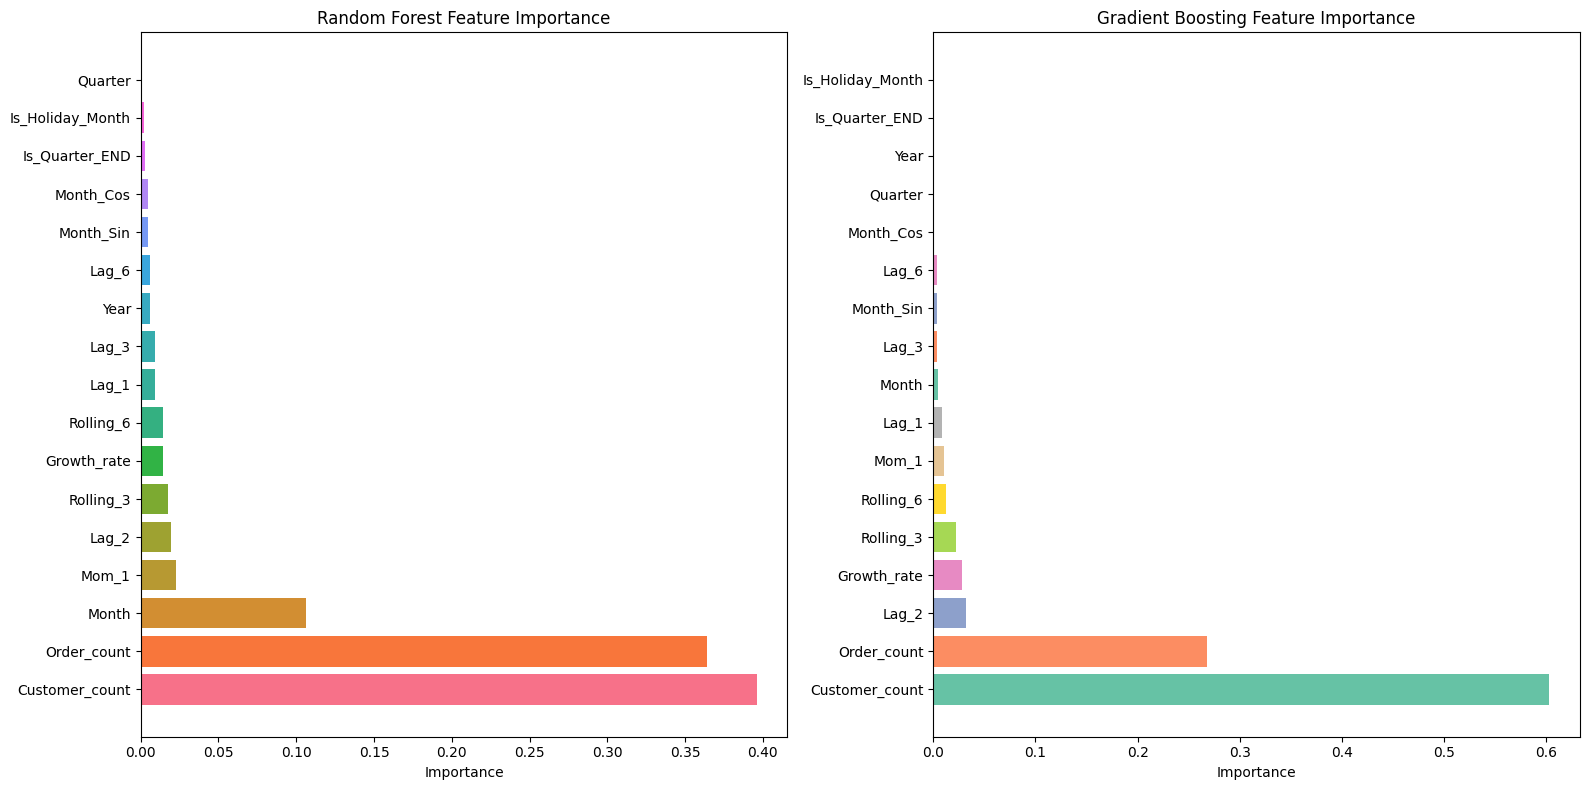

In [17]:
fig, axes = plt.subplots(1,2,figsize=(16,8))
axes[0].barh(
    rf_importance.index,
    rf_importance.values,
    color=sns.color_palette('husl', len(available))
)
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

axes[1].barh(
    gb_importance.index,
    gb_importance.values,
    color=sns.color_palette('Set2', len(available))
)
axes[1].set_title('Gradient Boosting Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('notebooks/09_feature_importance.png', dpi=150)
plt.show()

###Statistical Selection

In [18]:
selector_f = SelectKBest(score_func=f_regression, k='all')
selector_f.fit(X, y)
f_scores = pd.Series(selector_f.scores_, index=available).sort_values(ascending=False)
print('F-Regression Scores : ')
print(f_scores)

F-Regression Scores : 
Order_count         233.945703
Customer_count      219.470850
Month                44.525943
Quarter              30.576415
Mom_1                13.513619
Lag_1                 9.033833
Month_Sin             8.535808
Is_Holiday_Month      7.238318
Growth_rate           5.909167
Rolling_3             5.468223
Month_Cos             5.299446
Year                  5.197940
Is_Quarter_END        3.785112
Rolling_6             2.034009
Lag_3                 1.040590
Lag_2                 0.794482
Lag_6                 0.171772
dtype: float64


In [19]:
selector_mi = SelectKBest(score_func=mutual_info_regression, k='all')
selector_mi.fit(X, y)

mi_scores = pd.Series(selector_mi.scores_, index=available).sort_values(ascending=False)
print('Mutual Information Scores :')
print(mi_scores)

Mutual Information Scores :
Order_count         0.878108
Customer_count      0.853285
Month               0.510764
Quarter             0.444854
Month_Cos           0.425875
Rolling_3           0.283083
Lag_2               0.276993
Is_Holiday_Month    0.154830
Rolling_6           0.139580
Lag_6               0.121753
Year                0.075437
Lag_1               0.067176
Mom_1               0.065651
Month_Sin           0.064315
Growth_rate         0.016917
Lag_3               0.000213
Is_Quarter_END      0.000000
dtype: float64


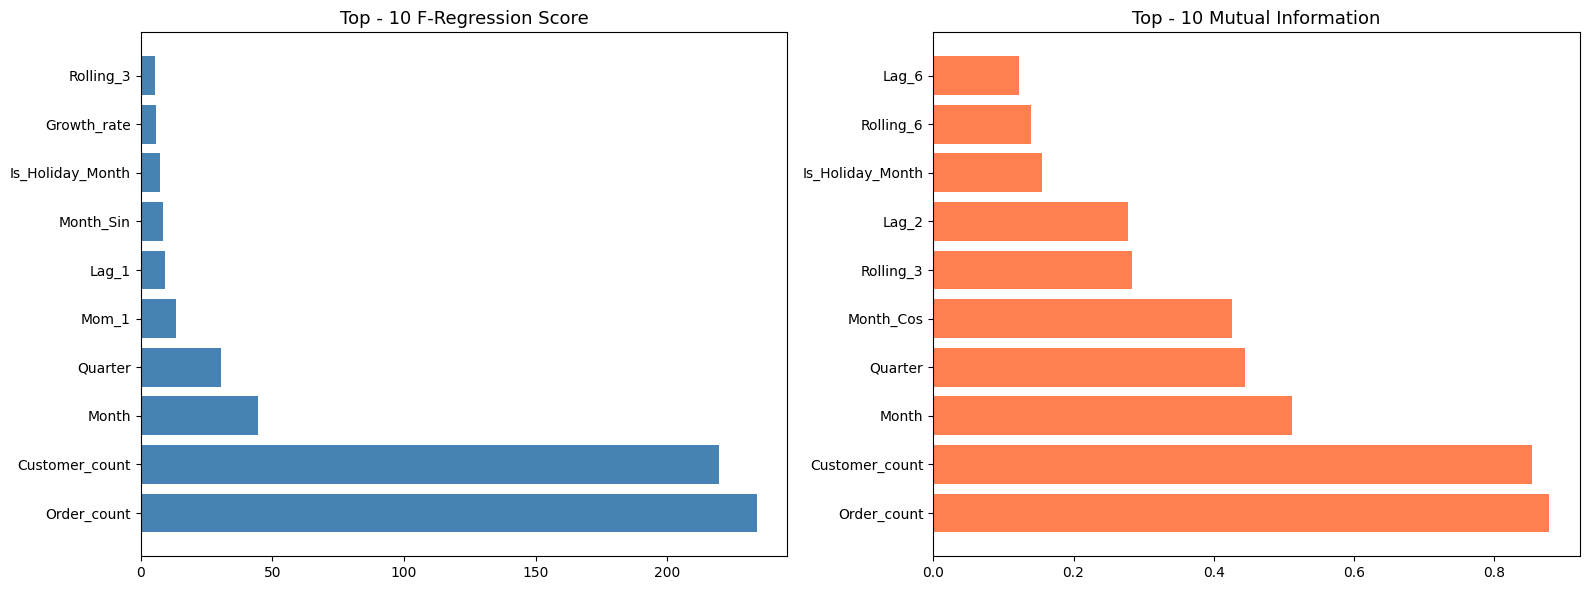

In [21]:
fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].barh(
    f_scores.index[:10],
    f_scores.values[:10],
    color='steelblue'
)
axes[0].set_title('Top - 10 F-Regression Score', fontsize=13)

axes[1].barh(
    mi_scores.index[:10],
    mi_scores.values[:10],
    color='coral'
)
axes[1].set_title('Top - 10 Mutual Information', fontsize=13)

plt.tight_layout()
plt.savefig('notebooks/10_statistical_selection.png', dpi=150)
plt.show()

###Final Feature Selection

In [23]:
features_scores = pd.DataFrame({
    'RF_Importance': rf_importance,
    'GB_Importance': gb_importance,
    'F_Regression': f_scores,
    'Mutual_Info': mi_scores,
    'Correlation': corr_with_target.abs()
})

for col in features_scores.columns:
  min_val = features_scores[col].min()
  max_val = features_scores[col].max()
  features_scores[f'{col}_norm'] = (features_scores[col] - min_val) / (max_val - min_val)

norm_cols = [c for c in features_scores.columns if '_norm' in c]
features_scores['Final Score'] = features_scores[norm_cols].mean(axis=1)

features_scores = features_scores.sort_values('Final Score', ascending=False)

print('Final Feature Score : ')
print(features_scores[['Final Score']].round(3))

Final Feature Score : 
                  Final Score
Customer_count          0.981
Order_count             0.873
Month                   0.367
Quarter                 0.270
Month_Cos               0.172
Rolling_3               0.155
Mom_1                   0.148
Is_Holiday_Month        0.122
Lag_1                   0.120
Month_Sin               0.112
Lag_2                   0.102
Growth_rate             0.098
Year                    0.092
Rolling_6               0.083
Is_Quarter_END          0.061
Lag_6                   0.031
Lag_3                   0.030


In [24]:
selected_features = features_scores[features_scores['Final Score'] > 0.2].index.tolist()
print(f'Selected Features : {len(selected_features)}')
for f in selected_features:
  print(f" -> {f}")

Selected Features : 4
 -> Customer_count
 -> Order_count
 -> Month
 -> Quarter


In [25]:
removed = [f for f in available if f not in selected_features]
print(f'Removed Features : {len(removed)}')
for f in removed:
  print(f" -> {f}")

Removed Features : 13
 -> Year
 -> Month_Sin
 -> Month_Cos
 -> Is_Holiday_Month
 -> Is_Quarter_END
 -> Lag_1
 -> Lag_2
 -> Lag_3
 -> Lag_6
 -> Rolling_3
 -> Rolling_6
 -> Mom_1
 -> Growth_rate


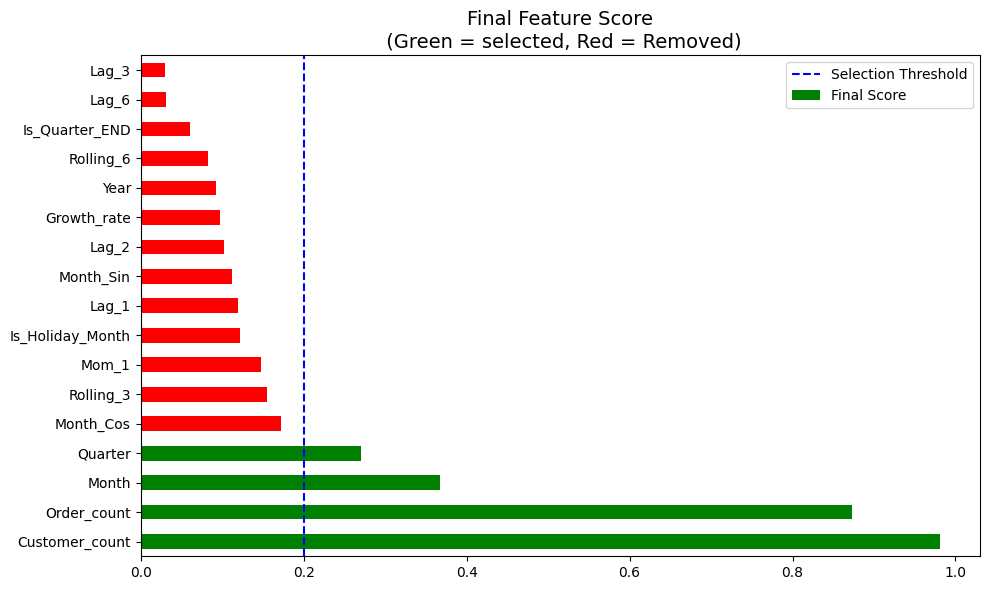

In [26]:
plt.figure(figsize=(10,6))
features_scores['Final Score'].sort_values(ascending=False).plot(
    kind='barh',
    color=['green' if x>0.2 else 'red' for x in features_scores['Final Score'].sort_values(ascending=False)]

)
plt.axvline(x=0.2, color='blue', linestyle='--', label='Selection Threshold')
plt.title('Final Feature Score\n (Green = selected, Red = Removed)', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('notebooks/11_final_features.png',dpi=150)
plt.show()

In [30]:
import json
import os

os.makedirs('data', exist_ok=True)
with open('data/selected_features.json', 'w') as f:
    json.dump(selected_features, f)